# Etapa 2 — Análise Exploratória de Dados (EDA)

Rode este notebook **a partir da pasta `notebooks/`** (os caminhos
apontam para `../data/raw`). A Etapa 1 (`uv run python src/scrape.py`)
precisa ter rodado antes.

Aqui vamos:
1. Carregar os quatro CSVs gerados pela Etapa 1.
2. Limpar e converter os tipos.
3. Explorar cada dataset isoladamente (marés, ondas, vento).
4. Juntar tudo numa única tabela horária (só na janela em que temos previsão).
5. Gerar visualizações que respondem perguntas sobre surf.
6. Salvar `data/processed/dataset.csv` para a Etapa 3.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DIR_RAW = Path("../data/raw")
DIR_PROC = Path("../data/processed")
DIR_PROC.mkdir(parents=True, exist_ok=True)

## 1. Carregar os CSVs

Quatro arquivos: `mares_2025.csv`, `mares_previsao.csv`, `ondas.csv` e
`vento.csv`. Se der `FileNotFoundError`, volte à Etapa 1 ou abra o
Jupyter de dentro de `notebooks/` (veja o README).

In [3]:
mares = pd.read_csv(DIR_RAW / "mares_2025.csv", parse_dates=["data"])
mares_prev = pd.read_csv(DIR_RAW / "mares_previsao.csv", parse_dates=["data"])
ondas = pd.read_csv(DIR_RAW / "ondas.csv", parse_dates=["data"])
vento = pd.read_csv(DIR_RAW / "vento.csv", parse_dates=["data"])

print("mares 2025:", mares.shape)
print("mares previsao:", mares_prev.shape)
print("ondas:", ondas.shape)
print("vento:", vento.shape)

mares 2025: (1410, 6)
mares previsao: (116, 6)
ondas: (144, 5)
vento: (168, 5)


In [4]:
mares.head()

,data,horario,altura_m,tipo,coeficiente,dia_ciclo_lunar
0,2025-01-01,5:50,2.4,alta,81,1
1,2025-01-01,12:00,0.4,baixa,81,1
2,2025-01-01,18:07,2.3,alta,81,1
3,2025-01-02,0:19,0.4,baixa,80,2
4,2025-01-02,6:31,2.4,alta,80,2


In [5]:
ondas.head()

,data,hora,direcao,valor,unidade
0,2026-06-05,0,ESE,1.3,m
1,2026-06-05,1,ESE,1.3,m
2,2026-06-05,2,ESE,1.3,m
3,2026-06-05,3,ESE,1.3,m
4,2026-06-05,4,ESE,1.3,m


In [6]:
vento.head()

,data,hora,direcao,valor,unidade
0,2026-06-05,0,S,17.0,km/h
1,2026-06-05,1,S,17.0,km/h
2,2026-06-05,2,S,16.0,km/h
3,2026-06-05,3,S,16.0,km/h
4,2026-06-05,4,S,17.0,km/h


## 2. Limpeza

- `horario` esta como string ("5:50") — convertemos para `time`.
- Criamos uma coluna `datahora` juntando data + horario, util para ordenar.
- Conferimos NaNs.

In [7]:
def adicionar_datahora(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["datahora"] = pd.to_datetime(
        df["data"].dt.strftime("%Y-%m-%d") + " " + df["horario"]
    )
    return df

mares = adicionar_datahora(mares).sort_values("datahora").reset_index(drop=True)
mares_prev = adicionar_datahora(mares_prev).sort_values("datahora").reset_index(drop=True)

print("NaNs em mares:")
print(mares.isna().sum())

NaNs em mares:
data               0
horario            0
altura_m           0
tipo               0
coeficiente        0
dia_ciclo_lunar    0
datahora           0
dtype: int64


In [8]:
# Para ondas e vento ja temos data + hora separados — montar datahora.
ondas["datahora"] = ondas["data"] + pd.to_timedelta(ondas["hora"], unit="h")
vento["datahora"] = vento["data"] + pd.to_timedelta(vento["hora"], unit="h")

## 3. Explorando cada dataset

### 3.1 Mares de 2025

In [9]:
mares["mes"] = mares["data"].dt.month
print(mares[["altura_m", "coeficiente"]].describe())

          altura_m  coeficiente
count  1410.000000  1410.000000
mean      1.367163    67.618440
std       0.861259    19.545233
min       0.000000    27.000000
25%       0.500000    52.000000
50%       1.350000    68.000000
75%       2.200000    82.000000
max       2.800000   114.000000


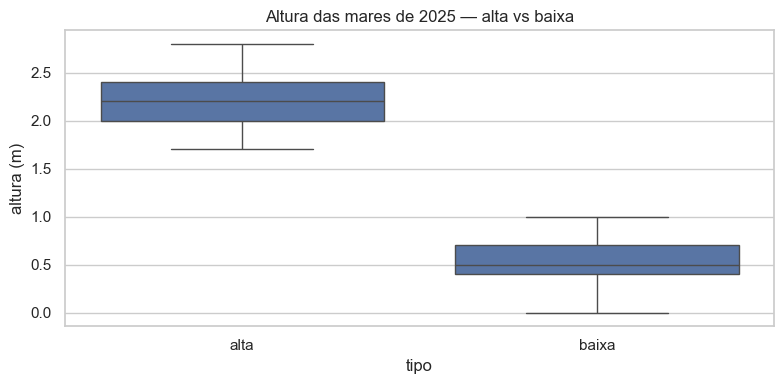

In [10]:
# Boxplot: distribuicao da altura por tipo (alta vs baixa)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=mares, x="tipo", y="altura_m", ax=ax)
ax.set_title("Altura das mares de 2025 — alta vs baixa")
ax.set_ylabel("altura (m)")
plt.tight_layout()
plt.show()

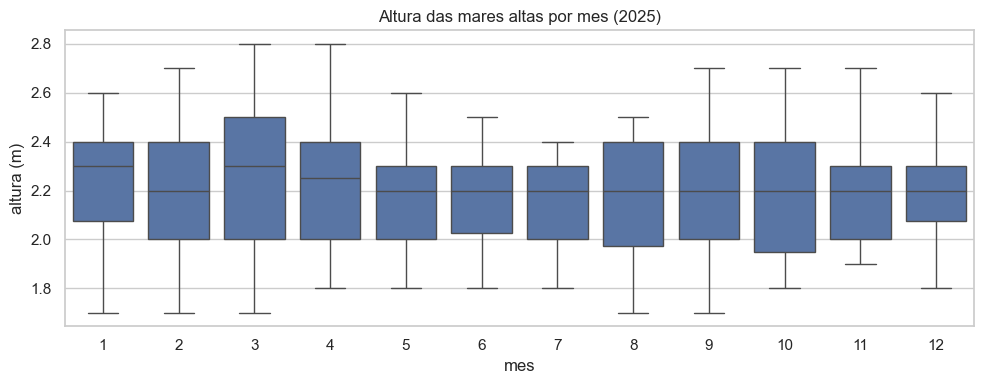

In [11]:
# Boxplot: altura das mares ALTAS por mes
mares_altas = mares[mares["tipo"] == "alta"]
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=mares_altas, x="mes", y="altura_m", ax=ax)
ax.set_title("Altura das mares altas por mes (2025)")
ax.set_xlabel("mes")
ax.set_ylabel("altura (m)")
plt.tight_layout()
plt.show()

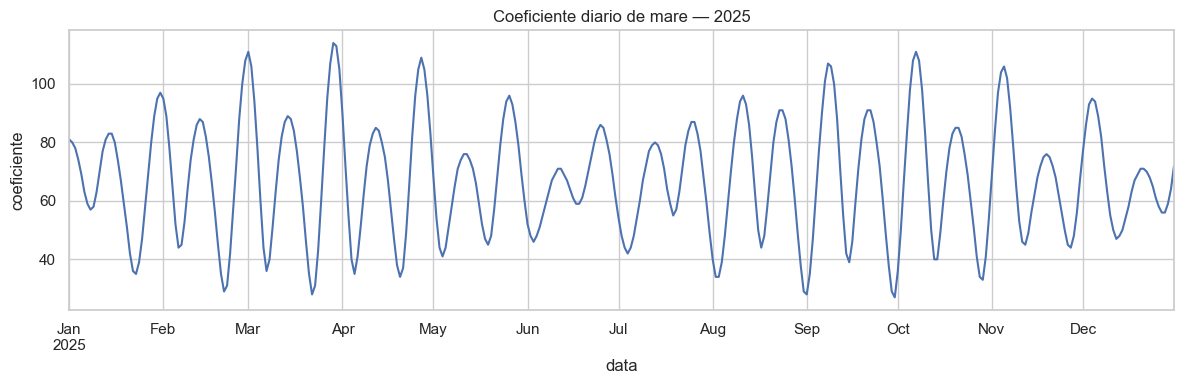

In [12]:
# Coeficiente medio por mes — picos sao luas cheias e novas (mares vivas)
fig, ax = plt.subplots(figsize=(12, 4))
mares.groupby("data")["coeficiente"].first().plot(ax=ax)
ax.set_title("Coeficiente diario de mare — 2025")
ax.set_ylabel("coeficiente")
plt.tight_layout()
plt.show()

### 3.2 Ondas (proximos dias)

In [13]:
print(ondas["valor"].describe())
print("\nDirecoes:", ondas["direcao"].value_counts().to_dict())

count    144.000000
mean       1.284722
std        0.062935
min        1.200000
25%        1.200000
50%        1.300000
75%        1.300000
max        1.400000
Name: valor, dtype: float64

Direcoes: {'ESE': 111, 'E': 33}


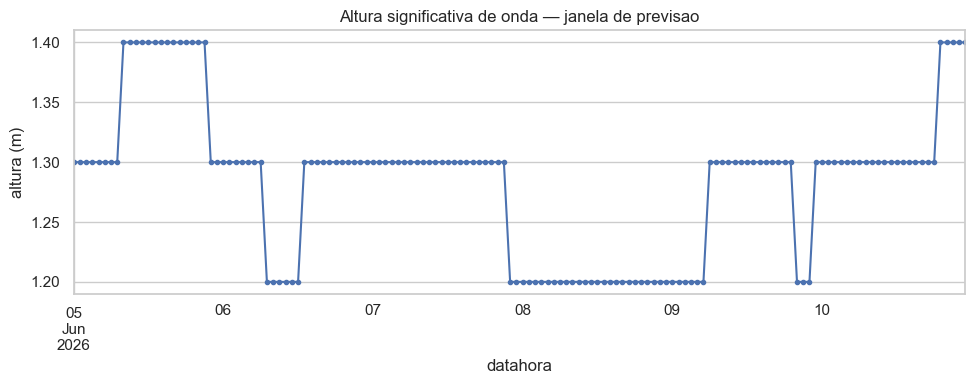

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ondas.set_index("datahora")["valor"].plot(ax=ax, marker="o", markersize=3)
ax.set_title("Altura significativa de onda — janela de previsao")
ax.set_ylabel("altura (m)")
plt.tight_layout()
plt.show()

### 3.3 Vento

In [15]:
print(vento["valor"].describe())
print("\nDirecoes:", vento["direcao"].value_counts().to_dict())

count    168.000000
mean      18.083333
std        2.902439
min       12.000000
25%       16.000000
50%       17.000000
75%       20.000000
max       25.000000
Name: valor, dtype: float64

Direcoes: {'SE': 55, 'S': 50, 'SSE': 41, 'ESE': 19, 'SSW': 3}


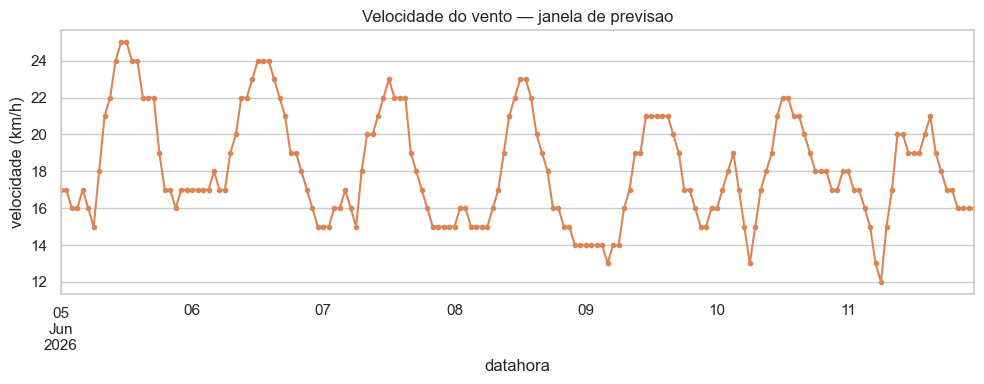

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
vento.set_index("datahora")["valor"].plot(ax=ax, marker="o", markersize=3, color="C1")
ax.set_title("Velocidade do vento — janela de previsao")
ax.set_ylabel("velocidade (km/h)")
plt.tight_layout()
plt.show()

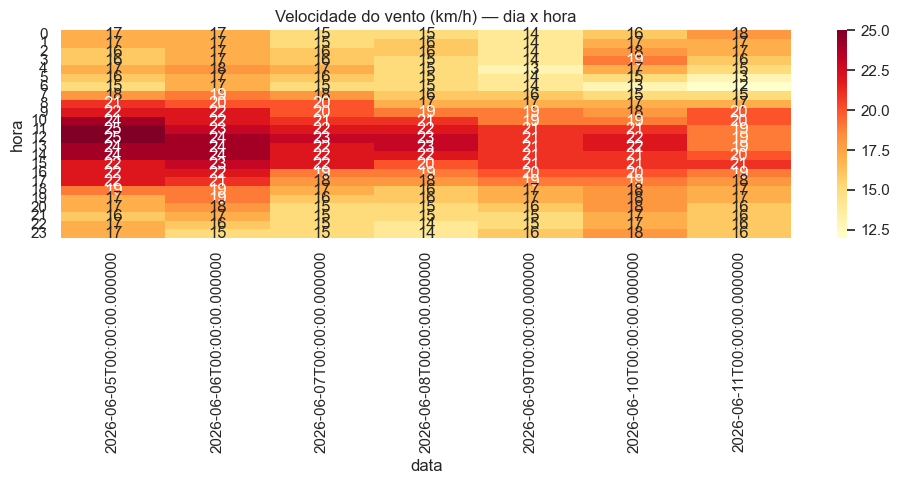

In [17]:
# Heatmap dia x hora do vento — onde estao as horas mais calmas?
piv = vento.pivot_table(index="hora", columns="data", values="valor", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Velocidade do vento (km/h) — dia x hora")
plt.tight_layout()
plt.show()

## 4. Juntando tudo (ondas + vento + mare interpolada)

Para a Etapa 3 precisamos de uma linha por hora com:
- altura da onda
- velocidade e direcao do vento
- altura interpolada da mare e se ela esta subindo

A interpolacao da mare e feita ligando os pontos (alta/baixa) por uma reta,
o que e uma simplificacao razoavel para fins didaticos (a curva real e
senoidal, mas a reta basta).

In [18]:
# 4.1 Juntar ondas e vento por datahora
ondas_v = ondas.rename(columns={"valor": "altura_onda_m", "direcao": "direcao_onda"})
vento_v = vento.rename(columns={"valor": "vento_kmh", "direcao": "direcao_vento"})

base = ondas_v[["datahora", "data", "hora", "altura_onda_m", "direcao_onda"]].merge(
    vento_v[["datahora", "vento_kmh", "direcao_vento"]],
    on="datahora",
    how="inner",
)
print("apos merge ondas+vento:", base.shape)

apos merge ondas+vento: (144, 7)


In [19]:
# 4.2 Interpolar mare hora a hora
# Usamos as mares do mes corrente (mares_previsao.csv).
serie_mare = mares_prev.set_index("datahora")["altura_m"].sort_index()

# Indice horario que cubra o range de base.datahora.
inicio = base["datahora"].min()
fim = base["datahora"].max()
indice_h = pd.date_range(inicio, fim, freq="h")

# Interpolacao linear entre as mares conhecidas.
mare_h = serie_mare.reindex(serie_mare.index.union(indice_h)).interpolate(method="time")
mare_h = mare_h.reindex(indice_h)

base["altura_mare_m"] = base["datahora"].map(mare_h)

In [20]:
# 4.3 mare_subindo: True se a altura da mare esta crescendo agora
# (compara com a mare anterior).
base = base.sort_values("datahora").reset_index(drop=True)
base["mare_subindo"] = base["altura_mare_m"].diff().fillna(0) > 0

In [21]:
# 4.4 Trazer coeficiente do dia (do mes_previsao)
coef_dia = mares_prev.groupby("data")["coeficiente"].first()
base["coeficiente"] = base["data"].map(coef_dia)

In [22]:
# 4.5 Features temporais
def periodo_dia(h: int) -> str:
    if 5 <= h < 12: return "manha"
    if 12 <= h < 18: return "tarde"
    if 18 <= h < 22: return "noite"
    return "madrugada"

base["dia_semana"] = base["datahora"].dt.day_name()
base["periodo_dia"] = base["hora"].apply(periodo_dia)

print(base.head())
print("\nshape final:", base.shape)
print("\nNaNs:")
print(base.isna().sum())

             datahora       data  hora  altura_onda_m direcao_onda  vento_kmh  \
0 2026-06-05 00:00:00 2026-06-05     0            1.3          ESE       17.0   
1 2026-06-05 01:00:00 2026-06-05     1            1.3          ESE       17.0   
2 2026-06-05 02:00:00 2026-06-05     2            1.3          ESE       16.0   
3 2026-06-05 03:00:00 2026-06-05     3            1.3          ESE       16.0   
4 2026-06-05 04:00:00 2026-06-05     4            1.3          ESE       17.0   

  direcao_vento  altura_mare_m  mare_subindo  coeficiente dia_semana  \
0             S       0.869811         False           53     Friday   
1             S       0.756757         False           53     Friday   
2             S       0.983784          True           53     Friday   
3             S       1.210811          True           53     Friday   
4             S       1.437838          True           53     Friday   

  periodo_dia  
0   madrugada  
1   madrugada  
2   madrugada  
3   madrugada  


## 5. Visualizacoes orientadas a surf

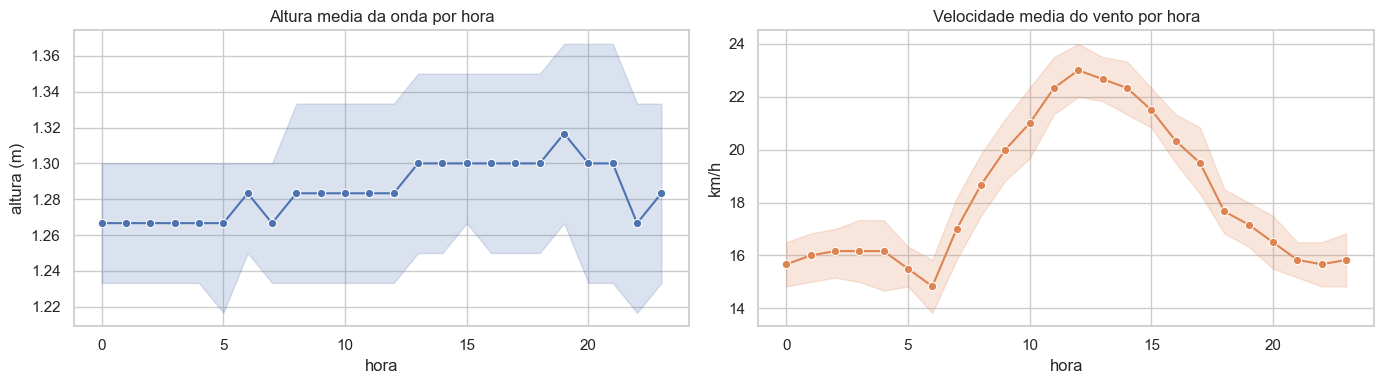

In [23]:
# 5.1 Quando a onda e maior x quando o vento e mais fraco?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=base, x="hora", y="altura_onda_m", ax=axes[0], marker="o")
axes[0].set_title("Altura media da onda por hora")
axes[0].set_ylabel("altura (m)")
sns.lineplot(data=base, x="hora", y="vento_kmh", ax=axes[1], marker="o", color="C1")
axes[1].set_title("Velocidade media do vento por hora")
axes[1].set_ylabel("km/h")
plt.tight_layout()
plt.show()

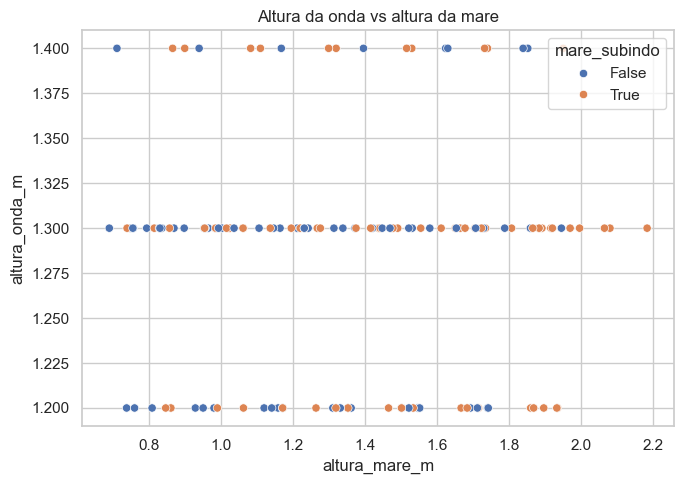

In [24]:
# 5.2 Onda x mare — existe relacao?
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=base, x="altura_mare_m", y="altura_onda_m",
                hue="mare_subindo", ax=ax)
ax.set_title("Altura da onda vs altura da mare")
plt.tight_layout()
plt.show()

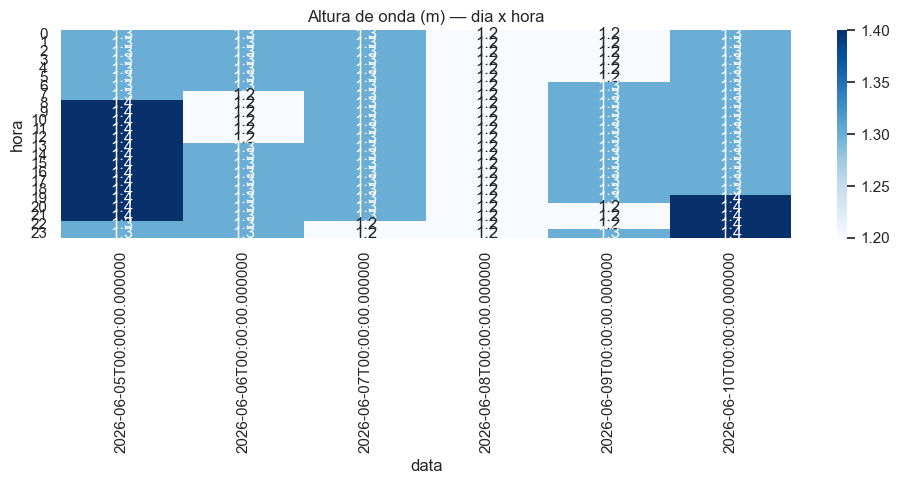

In [25]:
# 5.3 Heatmap dia x hora da altura de onda
piv_onda = base.pivot_table(index="hora", columns="data", values="altura_onda_m")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(piv_onda, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Altura de onda (m) — dia x hora")
plt.tight_layout()
plt.show()

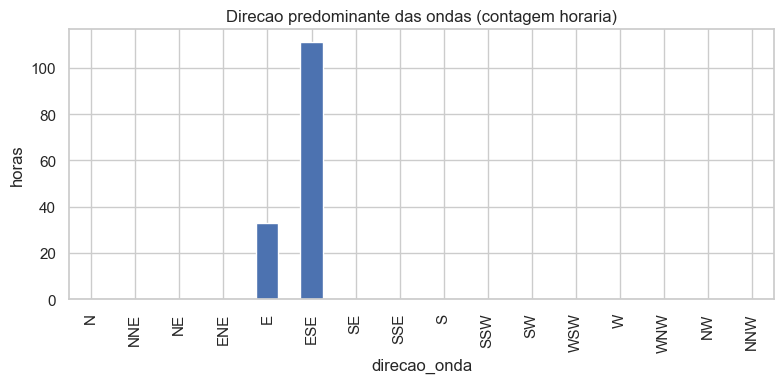

In [26]:
# 5.4 Direcao das ondas (rosa simplificada como contagem por direcao)
ordem_dir = ["N","NNE","NE","ENE","E","ESE","SE","SSE",
             "S","SSW","SW","WSW","W","WNW","NW","NNW"]
contagem = base["direcao_onda"].value_counts().reindex(ordem_dir).fillna(0)
fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot(kind="bar", ax=ax)
ax.set_title("Direcao predominante das ondas (contagem horaria)")
ax.set_ylabel("horas")
plt.tight_layout()
plt.show()

## 6. Salvar dataset processado

In [27]:
saida = DIR_PROC / "dataset.csv"
base.to_csv(saida, index=False)
print(f"salvo: {saida} ({len(base)} linhas)")

salvo: ../data/processed/dataset.csv (144 linhas)


## 7. Insights

Os números da previsão **mudam a cada execução** (a janela é só a da
semana corrente). Use os gráficos acima para confirmar ou corrigir os
pontos abaixo.

1. O coeficiente de maré oscila entre ~30 (marés mortas, perto dos
   quartos) e ~110 (marés vivas, em luas novas e cheias). Os picos
   coincidem com a mudança de fase da lua — isso vem do `mares_2025.csv`
   e não depende da janela curta.
2. Na janela de previsão, a altura da onda costuma variar pouco e vir de
   poucas direções. Olhe o `describe()` e o gráfico de direções desta
   execução — não copie números de uma rodada antiga.
3. O vento tende a ser mais forte à tarde e mais fraco de
   madrugada/manhã cedo — típico do litoral de João Pessoa. Confira no
   heatmap dia × hora.
4. Na Etapa 3 usamos `altura_onda_m`, `vento_kmh`, `altura_mare_m`,
   `mare_subindo`, `hora` e `coeficiente` para montar a label
   heurística de surfabilidade.